# Analisi benchmark: GFLOPS, Speedup, Efficienza e Best-approach
Notebook in italiano: carica le metriche CSV e crea i plot richiesti (GFLOPS vs N, Speedup, Efficiency, Best-approach).
Stile dei grafici ispirato a `omp_benchmark_analysis.ipynb` (palette calda/morbida, marker+linee, legenda ampia).

In [40]:
# Sezione 1: import librerie e impostazioni
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Matplotlib style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 2.2,
    'lines.markersize': 7
})
sns.set(style='whitegrid')

# Helper per percorsi relativi nel notebook
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))  # notebook sits in plot_scripts
DATA_DIR = os.path.join(os.getcwd(), 'metrics_tables')
print('DATA_DIR =', DATA_DIR)

DATA_DIR = /Users/irynasavchuk/Desktop/cartella senza nome/HPC-MATMUL/plot_scripts/metrics_tables


In [41]:
# Sezione 2: carico i CSV
seq_fp = os.path.join('metrics_tables', 'seq_all_metrics.csv')
omp_fp = os.path.join('metrics_tables', 'omp_all_metrics.csv')
mpi_fp = os.path.join('metrics_tables', 'mpi_all_metrics.csv')
cuda_fp = os.path.join('metrics_tables', 'cuda_all_metrics.csv')

print('Files:', seq_fp, omp_fp, mpi_fp, cuda_fp)

df_seq = pd.read_csv(seq_fp)
df_omp = pd.read_csv(omp_fp)
df_mpi = pd.read_csv(mpi_fp)
df_cuda = pd.read_csv(cuda_fp)

print('Shapes -> seq, omp, mpi, cuda:', df_seq.shape, df_omp.shape, df_mpi.shape, df_cuda.shape)
display(df_seq.head())

Files: metrics_tables/seq_all_metrics.csv metrics_tables/omp_all_metrics.csv metrics_tables/mpi_all_metrics.csv metrics_tables/cuda_all_metrics.csv
Shapes -> seq, omp, mpi, cuda: (184, 11) (680, 12) (288, 12) (72, 9)


,CPU,Compiler,Test,N,Align,Restrict,Threads/Ranks,TileSize,Time_s,GFLOPS,Speedup
0,12th Gen Intel(R) Core(TM) i9-12900K,gcc,seq-ikj,4096,0,0,1,-,19.69,6.98,1.00
1,12th Gen Intel(R) Core(TM) i9-12900K,gcc,seq-ikj,4096,1,1,1,-,20.44,6.72,0.96
2,12th Gen Intel(R) Core(TM) i9-12900K,gcc,seq-ikj,4100,0,0,1,-,18.96,7.27,1.43
3,12th Gen Intel(R) Core(TM) i9-12900K,gcc,seq-ikj,4100,1,1,1,-,20.41,6.75,1.33
4,12th Gen Intel(R) Core(TM) i9-12900K,gcc,seq-ikj,8192,0,0,1,-,170.23,6.46,1.00


In [42]:
# Sezione 3: pulizia e standardizzazione colonne
def prepare_df(df, source):
    df = df.copy()
    # lowercase strip columns
    df.columns = [c.strip() for c in df.columns]
    # unify names
    colmap = {
        'N': 'N', 'Time_s': 'time_s', 'GFLOPS': 'gflops', 'Threads/Ranks': 'p', 'TileSize': 'tile_size',
        'Test': 'test', 'Compiler': 'compiler', 'CPU':'cpu'
    }
    for k, v in colmap.items():
        if k in df.columns and v not in df.columns:
            df = df.rename(columns={k: v})
    # coerce numerics
    for ncol in ['N','time_s','gflops','p','tile_size']:
        if ncol in df.columns:
            df[ncol] = pd.to_numeric(df[ncol], errors='coerce')
    # normalize text columns
    for tcol in ['compiler','test','cpu']:
        if tcol in df.columns:
            df[tcol] = df[tcol].astype(str).str.strip().str.lower()
    df['source'] = source
    return df

df_seq = prepare_df(df_seq, 'seq')
df_omp = prepare_df(df_omp, 'omp')
df_mpi = prepare_df(df_mpi, 'mpi')
# cuda has different schema, harmonize minimal columns
df_cuda = df_cuda.rename(columns={ 'N':'N', 'GFLOPS':'gflops', 'Time_s':'time_s', 'Algorithm':'algorithm','cuBLAS':'cublas' })
df_cuda['p'] = 1
df_cuda['compiler'] = df_cuda.get('Configuration', '').astype(str)
df_cuda['test'] = df_cuda.get('Algorithm', '')
df_cuda['source'] = 'cuda'

# creiamo un unico DataFrame per comodità
df_all = pd.concat([df_seq, df_omp, df_mpi, df_cuda], ignore_index=True, sort=False)
print('Unified shape:', df_all.shape)
df_all.head()

Unified shape: (1224, 18)


,cpu,compiler,test,N,Align,Restrict,p,tile_size,time_s,gflops,Speedup,source,Efficiency_%,algorithm,Precision,BlockDim,TileSize,Configuration
0,12th gen intel(r) core(tm) i9-12900k,gcc,seq-ikj,4096,0.0,0.0,1,NaN,19.69,6.98,1.00,seq,NaN,NaN,NaN,NaN,NaN,NaN
1,12th gen intel(r) core(tm) i9-12900k,gcc,seq-ikj,4096,1.0,1.0,1,NaN,20.44,6.72,0.96,seq,NaN,NaN,NaN,NaN,NaN,NaN
2,12th gen intel(r) core(tm) i9-12900k,gcc,seq-ikj,4100,0.0,0.0,1,NaN,18.96,7.27,1.43,seq,NaN,NaN,NaN,NaN,NaN,NaN
3,12th gen intel(r) core(tm) i9-12900k,gcc,seq-ikj,4100,1.0,1.0,1,NaN,20.41,6.75,1.33,seq,NaN,NaN,NaN,NaN,NaN,NaN
4,12th gen intel(r) core(tm) i9-12900k,gcc,seq-ikj,8192,0.0,0.0,1,NaN,170.23,6.46,1.00,seq,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# Sezione 4b: helper functions per aggregazioni e best-config
def best_per_N(df, family, agg='max'):
    sub = df[df['family'] == family].dropna(subset=['N','gflops']).copy()
    if sub.empty:
        return pd.DataFrame()
    out = sub.groupby('N').apply(lambda g: g.loc[g['gflops'].idxmax()]).reset_index(drop=True)
    return out

def best_config(df, approach_filters):
    # approach_filters: list of (label, predicate) where predicate is a function accepting df and returning boolean mask
    rows = []
    for label, filt in approach_filters:
        mask = filt(df)
        # ensure mask is boolean Series with same index
        if isinstance(mask, pd.Series):
            if mask.dtype != bool:
                mask = mask.astype(bool)
        elif isinstance(mask, (np.ndarray, list)):
            mask = pd.Series(mask, index=df.index)
        else:
            raise TypeError(f"Filter for {label} must return a boolean Series or array")
        sub = df[mask].dropna(subset=['time_s','gflops'])
        if sub.empty:
            rows.append((label, None))
            continue
        idx = sub['gflops'].idxmax() if 'gflops' in sub.columns else sub['time_s'].idxmin()
        rows.append((label, sub.loc[idx]))
    return rows

def compute_speedup(df, baseline_df, by=['N','compiler','test']):
    # baseline_df holds p==1 baseline times per grouping
    # baseline may contain 'time_s' or already 'time_s_baseline'
    if 'time_s' in baseline_df.columns:
        baseline_col = 'time_s'
    elif 'time_s_baseline' in baseline_df.columns:
        baseline_col = 'time_s_baseline'
    else:
        raise KeyError("baseline_df must contain 'time_s' or 'time_s_baseline' column")

    merged = df.merge(baseline_df[[*by, baseline_col]], on=by, how='left')
    if baseline_col != 'time_s_baseline':
        merged = merged.rename(columns={baseline_col: 'time_s_baseline'})
    merged['speedup'] = merged['time_s_baseline'] / merged['time_s']
    return merged

def compute_efficiency(df):
    df = df.copy()
    df['efficiency'] = df['speedup'] / df['p'] * 100.0
    return df


In [44]:
# Sezione 4b: helper functions per aggregazioni e best-config
def best_per_N(df, family, agg='max'):
    sub = df[df['family'] == family].dropna(subset=['N','gflops']).copy()
    if sub.empty:
        return pd.DataFrame()
    out = sub.groupby('N').apply(lambda g: g.loc[g['gflops'].idxmax()]).reset_index(drop=True)
    return out

def best_config(df, approach_filters):
    # approach_filters: list of predicates (lambda row: bool) or (family, optional test) tuples
    rows = []
    for label, filt in approach_filters:
        sub = df[filt(df)].dropna(subset=['time_s','gflops'])
        if sub.empty:
            rows.append((label, None))
            continue
        idx = sub['gflops'].idxmax() if 'gflops' in sub.columns else sub['time_s'].idxmin()
        rows.append((label, sub.loc[idx]))
    return rows

def compute_speedup(df, baseline_df, by=['N','compiler','test']):
    # baseline_df holds p==1 baseline times per grouping
    merged = df.merge(baseline_df[[*by, 'time_s']], on=by, how='left', suffixes=('', '_baseline'))
    merged['speedup'] = merged['time_s_baseline'] / merged['time_s']
    return merged

def compute_efficiency(df):
    df = df.copy()
    df['efficiency'] = df['speedup'] / df['p'] * 100.0
    return df

In [45]:
# Sezione 5: palette e stile coerente con omp_notebook
PALETTE = {
    'warm_orange': '#D98B5F',
    'muted_purple': '#6C6FA8',
    'desaturated_teal': '#4F7C82',
    'cuda': '#D9534F',
    'mkl': '#5F6F7A',
    'scalapack': '#7A9E7E'
}
def minimal_axes(ax, show_yticks=True):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis='both', which='both', length=0)
    if not show_yticks:
        ax.set_yticks([])

print('Palette:', PALETTE)

Palette: {'warm_orange': '#D98B5F', 'muted_purple': '#6C6FA8', 'desaturated_teal': '#4F7C82', 'cuda': '#D9534F', 'mkl': '#5F6F7A', 'scalapack': '#7A9E7E'}


In [46]:
# Sezione 6: GFLOPS vs N per famiglia (seq, omp, mpi, cuda) - crea una figura separata per famiglia
families = ['seq','omp','mpi','cuda']
outdir = os.path.join('figures')
os.makedirs(outdir, exist_ok=True)
# tick values richieste dall'utente
requested_N = [4100, 8200, 12300, 16400]
for fam in families:
    best = best_per_N(df_all, fam)
    fig, ax = plt.subplots(figsize=(7,5))
    if best.empty:
        ax.text(0.5, 0.5, 'no data', ha='center')
    else:
        comps = best['compiler'].fillna('unknown').unique()
        for comp in sorted(comps):
            sel = best[best['compiler']==comp]
            ax.plot(sel['N'], sel['gflops'], marker='o', label=comp.upper(), linewidth=2.4)
        ax.set_xscale('log', base=2)
        ax.set_xlabel('N')
        ax.set_ylabel('GFLOPS')
        ax.set_title(fam.upper())
        ax.legend(frameon=False, loc='best')
        # forza i tick richiesti (mostrati anche se scala log)
        ax.set_xticks(requested_N)
    minimal_axes(ax)
    plt.tight_layout()
    fname = os.path.join(outdir, f'gflops_{fam}.png')
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    display(fig)
    plt.close(fig)


KeyError: 'family'

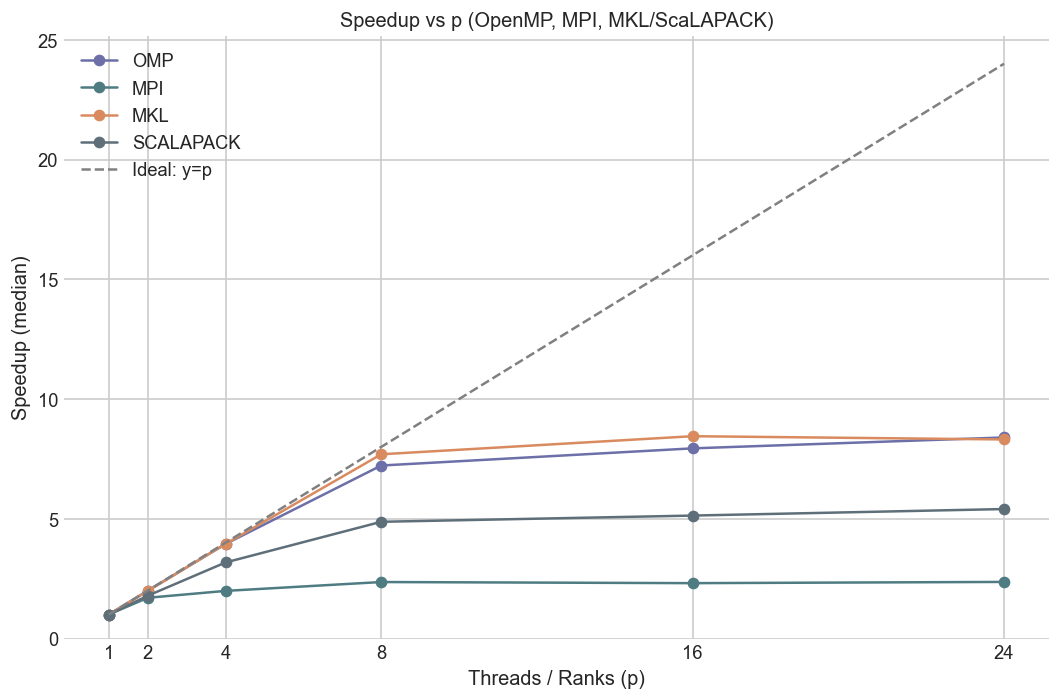

In [ ]:
# Sezione 7: Speedup vs p per OpenMP, MPI e MKL/ScaLAPACK (disegna y=p ideale)
speed_families = ['omp','mpi','mkl','scalapack']
fig, ax = plt.subplots(figsize=(9,6))
colors = ['#6C6FA8', '#4F7C82', '#D98B5F', '#5F6F7A']
for fam, col in zip(speed_families, colors):
    sub = df_all[df_all['family'].isin([fam])].dropna(subset=['p','time_s'])
    if sub.empty:
        continue
    # baseline: p==1 for same test/compiler/N
    baseline = sub[sub['p']==1][['N','compiler','test','time_s']].rename(columns={'time_s':'time_s_baseline'})
    merged = compute_speedup(sub, baseline, by=['N','compiler','test'])
    # aggregate median speedup per p
    agg = merged.groupby('p')['speedup'].median().reset_index()
    ax.plot(agg['p'], agg['speedup'], marker='o', label=fam.upper(), color=col)
# ideal line y=p
pvals = np.array(sorted(df_all['p'].dropna().unique()))
if len(pvals)>0:
    ax.plot(pvals, pvals, color='gray', linestyle='--', label='Ideal: y=p')
ax.set_xscale('linear')
ax.set_xlabel('Threads / Ranks (p)')
ax.set_ylabel('Speedup (median)')
ax.set_xticks([1,2,4,8,16,24])
ax.set_ylim(bottom=0)
minimal_axes(ax)
ax.legend(frameon=False, loc='upper left')
ax.set_title('Speedup vs p (OpenMP, MPI, MKL/ScaLAPACK)')
plt.tight_layout()
plt.show()

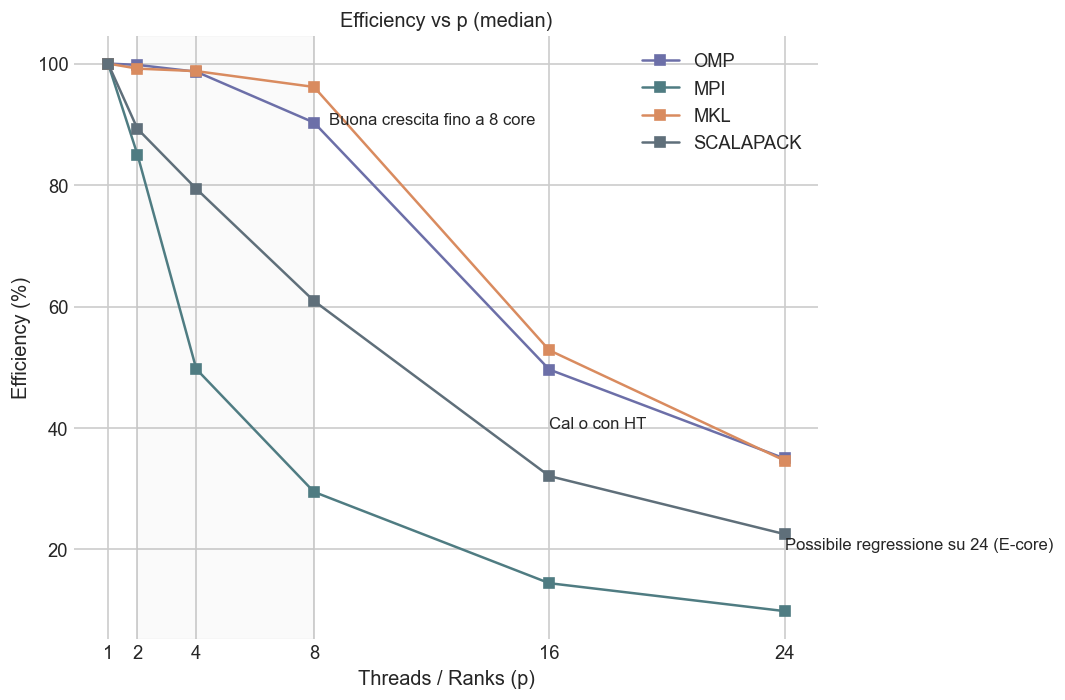

In [ ]:
# Sezione 8: Efficiency vs p per OpenMP, MPI, MKL/ScaLAPACK
fig, ax = plt.subplots(figsize=(9,6))
for fam, col in zip(speed_families, colors):
    sub = df_all[df_all['family']==fam].dropna(subset=['p','time_s'])
    if sub.empty:
        continue
    baseline = sub[sub['p']==1][['N','compiler','test','time_s']].rename(columns={'time_s':'time_s_baseline'})
    merged = compute_speedup(sub, baseline, by=['N','compiler','test'])
    merged = compute_efficiency(merged)
    agg = merged.groupby('p')['efficiency'].median().reset_index()
    ax.plot(agg['p'], agg['efficiency'], marker='s', label=fam.upper(), color=col)
# annotate typical behavior text
ax.axvspan(2,8, color='gray', alpha=0.04)
ax.text(8.5, 90, 'Buona crescita fino a 8 core', fontsize=10)
ax.text(16, 40, 'Cal o con HT', fontsize=10)
ax.text(24, 20, 'Possibile regressione su 24 (E-core)', fontsize=10)
ax.set_xlabel('Threads / Ranks (p)')
ax.set_ylabel('Efficiency (%)')
ax.set_xticks([1,2,4,8,16,24])
minimal_axes(ax)
ax.legend(frameon=False, loc='upper right')
ax.set_title('Efficiency vs p (median)')
plt.tight_layout()
plt.show()

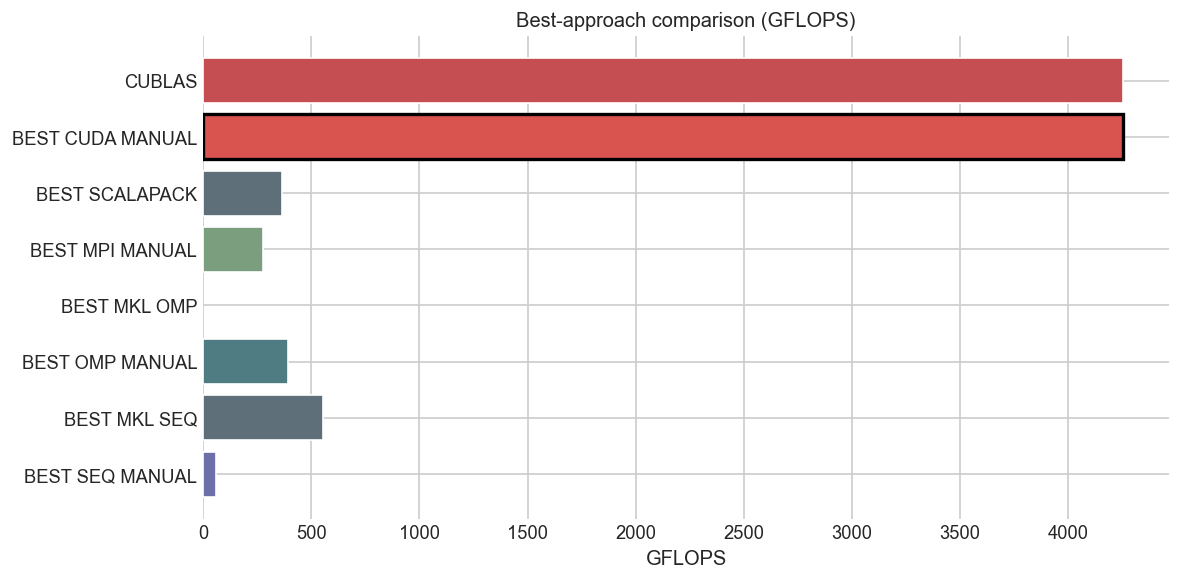

In [ ]:
# Sezione 9: Best-approach comparison
# definire i filtri per i 8 approcci richiesti
approaches = [
    ('best_seq_manual', lambda df: (df['family'] == 'seq'))
    ,('best_mkl_seq', lambda df: (df['test'].str.contains('mkl', case=False, na=False)) | (df['compiler'].str.contains('mkl', na=False)))
    ,('best_omp_manual', lambda df: (df['family'] == 'omp') & (~df['test'].str.contains('mkl', case=False, na=False)))
    ,('best_mkl_omp', lambda df: (df['family'] == 'omp') & ((df['test'].str.contains('mkl', case=False, na=False)) | (df['compiler'].str.contains('mkl', na=False))))
    ,('best_mpi_manual', lambda df: (df['family'] == 'mpi') & (~df['test'].str.contains('scalapack', case=False, na=False)))
    ,('best_scalapack', lambda df: (df['test'].str.contains('scalapack', case=False, na=False)) | (df['family'] == 'scalapack'))
    ,('best_cuda_manual', lambda df: (df['family'] == 'cuda') & (~df['test'].str.contains('cublas', case=False, na=False)))
    ,('cublas', lambda df: (df['test'].str.contains('cublas', case=False, na=False)) | (pd.Series(df.get('algorithm', ''), index=df.index).astype(str).str.contains('cublas', case=False, na=False)))
]
best_rows = best_config(df_all, approaches)
# prepara dati per il plot
labels = []
gflops_vals = []
for label, row in best_rows:
    labels.append(label)
    if row is None:
        gflops_vals.append(np.nan)
    else:
        gflops_vals.append(float(row.get('gflops', np.nan)))
# plot orizzontale per evidenziare confronto
fig, ax = plt.subplots(figsize=(10,5))
y = np.arange(len(labels))
ax.barh(y, gflops_vals, color=['#6C6FA8','#5F6F7A','#4F7C82','#D98B5F','#7A9E7E','#5F6F7A','#D9534F','#C44E52'])
ax.set_yticks(y)
ax.set_yticklabels([l.replace('_',' ').upper() for l in labels])
ax.set_xlabel('GFLOPS')
ax.set_title('Best-approach comparison (GFLOPS)')
minimal_axes(ax, show_yticks=True)
# evidenzia il migliore
best_idx = np.nanargmax(gflops_vals) if any(np.isfinite(gflops_vals)) else None
if best_idx is not None:
    ax.get_children()[best_idx].set_edgecolor('black')
    ax.get_children()[best_idx].set_linewidth(2)
plt.tight_layout()
plt.show()

In [ ]:
# Sezione 10: funzioni per salvare figure e esportare tabella riassuntiva
def save_fig(fig, name, folder='figures'):
    os.makedirs(folder, exist_ok=True)
    for ext in ['png','svg']:
        path = os.path.join(folder, f'{name}.{ext}')
        fig.savefig(path, bbox_inches='tight', dpi=300)
    print('Saved:', name)

# salva tabella best-config in CSV
best_table = []
for label, row in best_rows:
    if row is None:
        best_table.append({'approach':label, 'gflops':np.nan, 'time_s':np.nan, 'config':None})
    else:
        best_table.append({'approach':label, 'gflops':row.get('gflops', np.nan), 'time_s':row.get('time_s', np.nan), 'config':row.to_dict()})
pd.DataFrame(best_table).to_csv('best_approaches_summary.csv', index=False)
print('Wrote best_approaches_summary.csv')

Wrote best_approaches_summary.csv


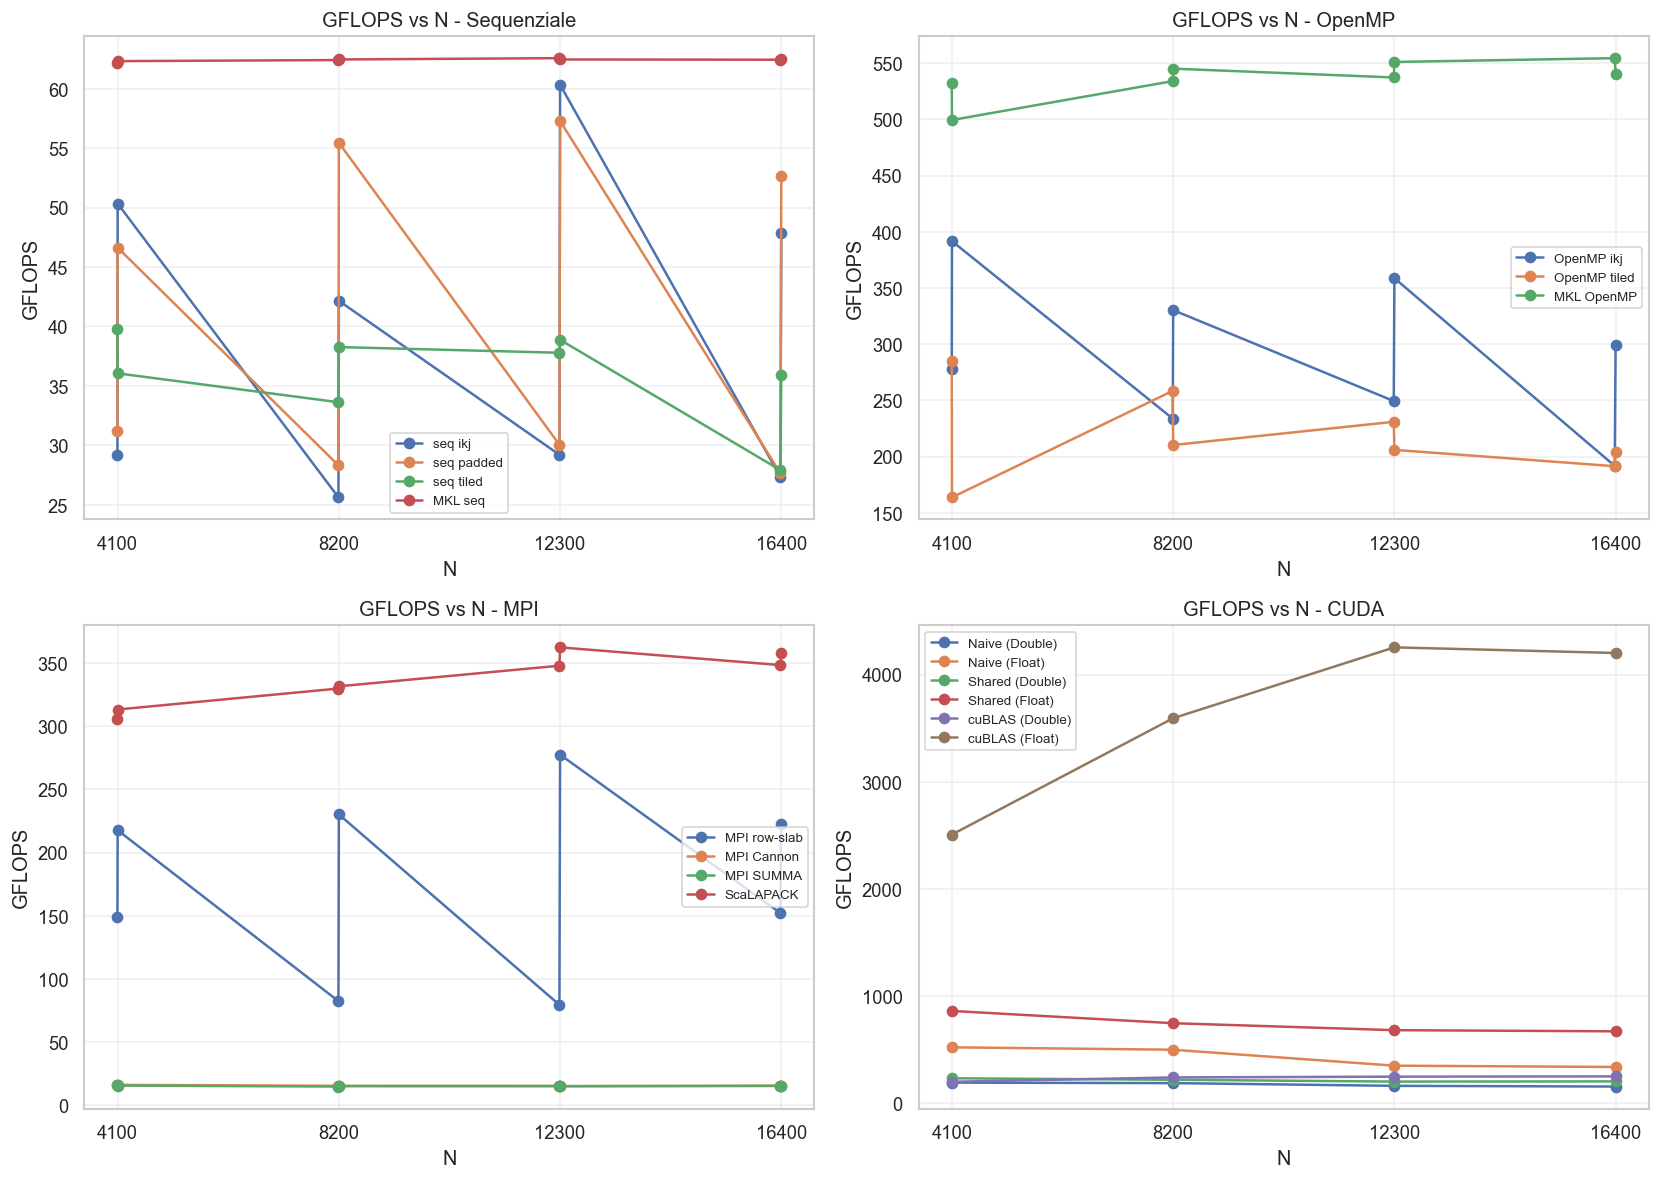

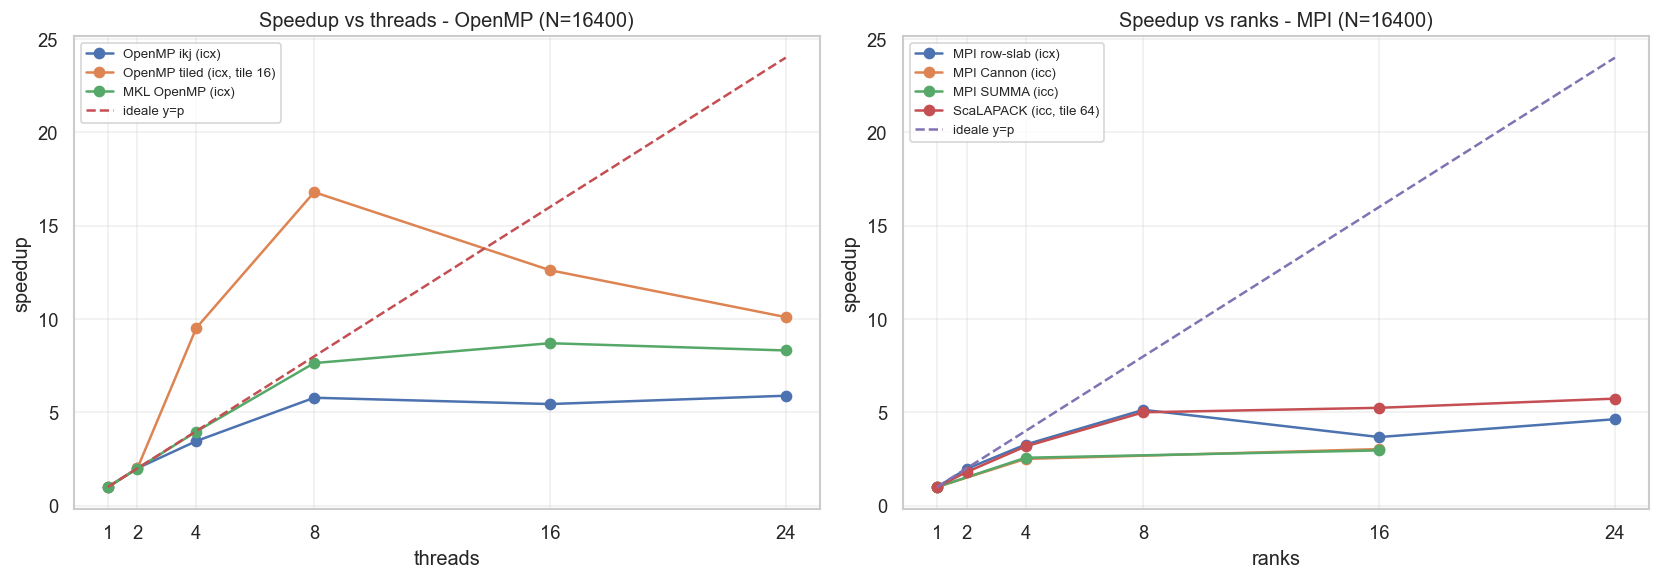

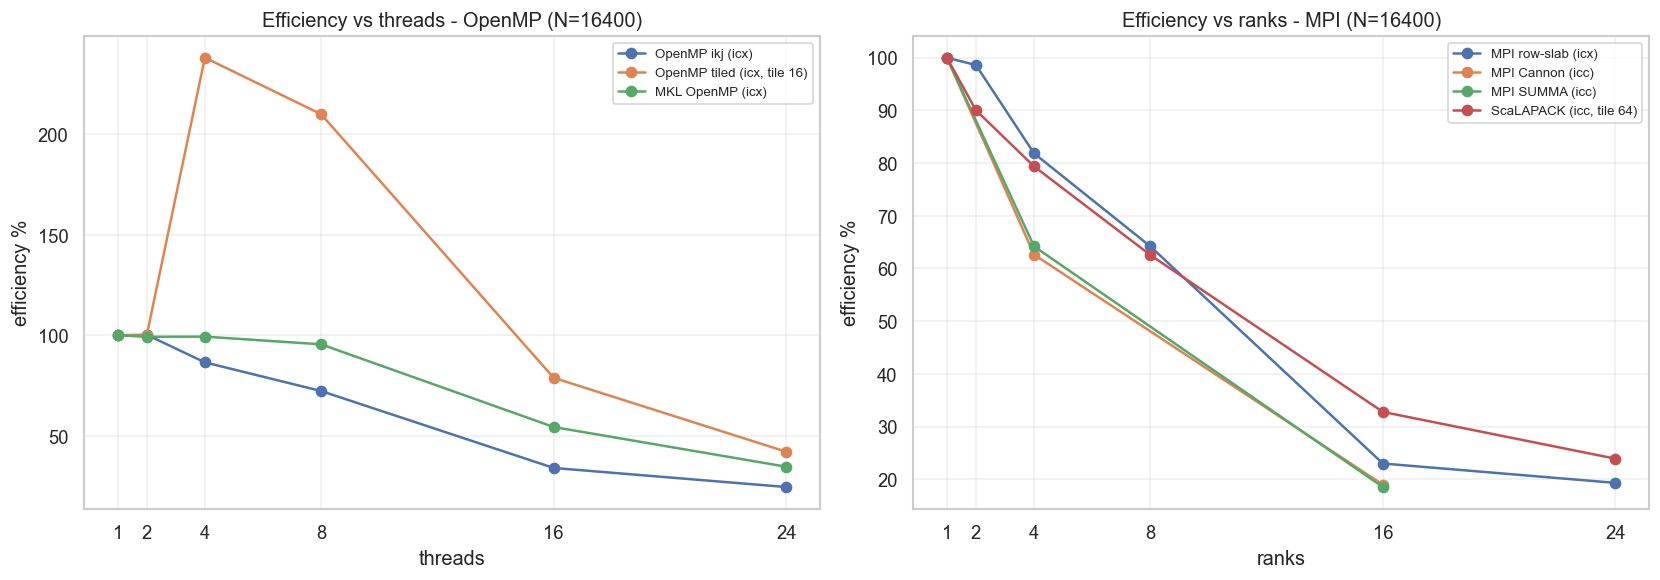

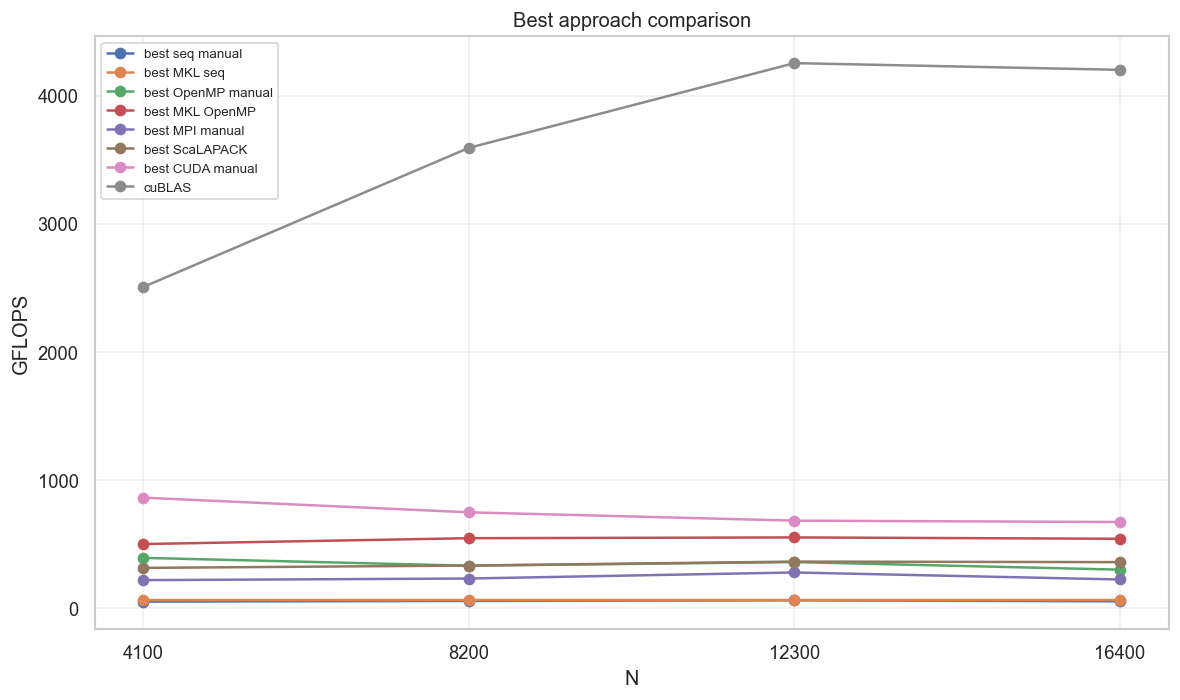

N usato per scaling: 16400

Configurazioni scelte per OpenMP:
 - OpenMP ikj (icx)
 - OpenMP tiled (icx, tile 16)
 - MKL OpenMP (icx)

Configurazioni scelte per MPI:
 - MPI row-slab (icx)
 - MPI Cannon (icc)
 - MPI SUMMA (icc)
 - ScaLAPACK (icc, tile 64)

N comuni per il confronto finale: [4100, 8200, 12300, 16400]


In [48]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametro principale
# =========================
N_SCALE = 16400   # N usato per speedup/efficiency

# =========================
# Lettura CSV
# =========================
def load_csv(filename):
    # prova più possibili posizioni relative e absolute in ordine
    candidates = [
        Path(filename),
        Path('metrics_tables') / filename,
        Path('plot_scripts') / 'metrics_tables' / filename,
        Path.cwd() / 'plot_scripts' / 'metrics_tables' / filename,
        Path.cwd() / 'metrics_tables' / filename,
        Path('/Users/irynasavchuk/Desktop/cartella senza nome/HPC-MATMUL/plot_scripts/metrics_tables') / filename,
    ]
    for p in candidates:
        if p.exists():
            return pd.read_csv(p)
    # fallback: cerca ricorsivamente nel progetto
    matches = list(Path('.').rglob(filename))
    if matches:
        return pd.read_csv(matches[0])
    raise FileNotFoundError(f"File non trovato: {filename}; cercati: {candidates}")

seq = load_csv("seq_all_metrics.csv")
omp = load_csv("omp_all_metrics.csv")
mpi = load_csv("mpi_all_metrics.csv")
cuda = load_csv("cuda_all_metrics.csv")

for df in (seq, omp, mpi, cuda):
    if "TileSize" in df.columns:
        df["TileSize"] = df["TileSize"].fillna("-").astype(str)
    if "Threads/Ranks" in df.columns:
        df["Threads/Ranks"] = pd.to_numeric(df["Threads/Ranks"], errors="coerce")

# =========================
# Etichette più leggibili
# =========================
nice = {
    "seq-ikj": "seq ikj",
    "seq-pad": "seq padded",
    "seq-tile": "seq tiled",
    "mkl-seq": "MKL seq",
    "omp-ikj": "OpenMP ikj",
    "omp-tile": "OpenMP tiled",
    "mkl-omp": "MKL OpenMP",
    "mpi-ikj": "MPI row-slab",
    "mpi-cannon": "MPI Cannon",
    "mpi-summa": "MPI SUMMA",
    "scalapack": "ScaLAPACK",
}

# =========================
# Helper
# =========================
def best_per_n(df, category_col, categories=None, n_values=None):
    """
    Per ogni categoria e per ogni N prende il record con GFLOPS massimo.
    Serve per i plot GFLOPS vs N e best comparison.
    """
    work = df.copy()
    if categories is None:
        categories = list(work[category_col].dropna().unique())

    rows = []
    for cat in categories:
        dcat = work[work[category_col] == cat]
        for n, g in dcat.groupby("N"):
            if (n_values is not None) and (n not in n_values):
                continue
            best = g.sort_values(["GFLOPS", "Time_s"], ascending=[False, True]).iloc[0]
            rows.append({
                "category": cat,
                "N": n,
                "GFLOPS": best["GFLOPS"]
            })
    return pd.DataFrame(rows)

def choose_best_scaling_config(df, test_name, n_value):
    """
    Sceglie UNA configurazione fissa per fare speedup/efficiency:
    stessa implementazione, stesso compiler, stesso tile, stesso align/restrict.
    Poi ricalcola speedup ed efficiency da Time_s usando come baseline p=1.
    """
    d = df[(df["Test"] == test_name) & (df["N"] == n_value)].copy()

    metric_cols = {"N", "Threads/Ranks", "Time_s", "GFLOPS", "Speedup", "Efficiency_%"}
    config_cols = [c for c in d.columns if c not in metric_cols | {"Test"}]

    candidates = []
    for key, g in d.groupby(config_cols, dropna=False):
        pr = sorted(g["Threads/Ranks"].dropna().astype(int).unique())

        # serve almeno il baseline 1 e almeno un altro punto
        if 1 not in pr or len(pr) < 2:
            continue

        # riduce eventuali duplicati sullo stesso p/rank
        reduced = g.groupby("Threads/Ranks", as_index=False).agg({
            "Time_s": "min",
            "GFLOPS": "max"
        }).sort_values("Threads/Ranks")

        base = reduced.loc[reduced["Threads/Ranks"] == 1, "Time_s"]
        if base.empty:
            continue

        base_t = float(base.iloc[0])
        reduced["Speedup_calc"] = base_t / reduced["Time_s"]
        reduced["Efficiency_calc"] = 100.0 * reduced["Speedup_calc"] / reduced["Threads/Ranks"]

        # prende la configurazione che raggiunge il GFLOPS massimo più alto
        score = reduced["GFLOPS"].max()

        if not isinstance(key, tuple):
            key = (key,)
        cfg = dict(zip(config_cols, key))
        cfg["Test"] = test_name

        candidates.append((score, cfg, reduced))

    if not candidates:
        return None, None

    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates[0][1], candidates[0][2]

def config_to_label(config):
    label = nice.get(config["Test"], config["Test"])
    extras = []
    if "Compiler" in config and pd.notna(config["Compiler"]):
        extras.append(str(config["Compiler"]))
    if "TileSize" in config and str(config["TileSize"]) not in ["-", "nan"]:
        extras.append(f"tile {config['TileSize']}")
    return f"{label} ({', '.join(extras)})" if extras else label

# =========================
# 1) GFLOPS vs N per famiglia
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# forzare i tick di N richiesti dall'utente
requested_N = [4100, 8200, 12300, 16400]

family_specs = [
    (
        seq,
        "Test",
        ["seq-ikj", "seq-pad", "seq-tile", "mkl-seq"],
        "GFLOPS vs N - Sequenziale"
    ),
    (
        omp,
        "Test",
        ["omp-ikj", "omp-tile", "mkl-omp"],
        "GFLOPS vs N - OpenMP"
    ),
    (
        mpi,
        "Test",
        ["mpi-ikj", "mpi-cannon", "mpi-summa", "scalapack"],
        "GFLOPS vs N - MPI"
    ),
    (
        cuda.assign(Cat=cuda["Algorithm"] + " (" + cuda["Precision"] + ")"),
        "Cat",
        sorted((cuda["Algorithm"] + " (" + cuda["Precision"] + ")").unique()),
        "GFLOPS vs N - CUDA"
    ),
]

for ax, (df, cat_col, cats, title) in zip(axes.flat, family_specs):
    curve = best_per_n(df, cat_col, cats)
    for cat in cats:
        s = curve[curve["category"] == cat].sort_values("N")
        if not s.empty:
            ax.plot(s["N"], s["GFLOPS"], marker="o", label=nice.get(cat, cat))
    ax.set_title(title)
    ax.set_xlabel("N")
    ax.set_ylabel("GFLOPS")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    # Forza i tick richiesti per N (anche se scala log)
    try:
        ax.set_xticks(requested_N)
        ax.set_xticklabels([str(x) for x in requested_N])
    except Exception:
        pass

fig.tight_layout()
plt.show()

# =========================
# 2) Speedup vs thread/rank
# =========================
omp_tests = ["omp-ikj", "omp-tile", "mkl-omp"]
mpi_tests = ["mpi-ikj", "mpi-cannon", "mpi-summa", "scalapack"]

omp_curves = []
for t in omp_tests:
    cfg, curve = choose_best_scaling_config(omp, t, N_SCALE)
    if curve is not None:
        omp_curves.append((cfg, curve))

mpi_curves = []
for t in mpi_tests:
    cfg, curve = choose_best_scaling_config(mpi, t, N_SCALE)
    if curve is not None:
        mpi_curves.append((cfg, curve))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OpenMP
for cfg, curve in omp_curves:
    axes[0].plot(curve["Threads/Ranks"], curve["Speedup_calc"], marker="o", label=config_to_label(cfg))
if omp_curves:
    x_omp = sorted(set(np.concatenate([c["Threads/Ranks"].values for _, c in omp_curves])))
    axes[0].plot(x_omp, x_omp, linestyle="--", label="ideale y=p")
axes[0].set_title(f"Speedup vs threads - OpenMP (N={N_SCALE})")
axes[0].set_xlabel("threads")
axes[0].set_ylabel("speedup")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
axes[0].set_xticks([1,2,4,8,16,24])

# MPI
for cfg, curve in mpi_curves:
    axes[1].plot(curve["Threads/Ranks"], curve["Speedup_calc"], marker="o", label=config_to_label(cfg))
if mpi_curves:
    x_mpi = sorted(set(np.concatenate([c["Threads/Ranks"].values for _, c in mpi_curves])))
    axes[1].plot(x_mpi, x_mpi, linestyle="--", label="ideale y=p")
axes[1].set_title(f"Speedup vs ranks - MPI (N={N_SCALE})")
axes[1].set_xlabel("ranks")
axes[1].set_ylabel("speedup")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)
axes[1].set_xticks([1,2,4,8,16,24])

fig.tight_layout()
plt.show()

# =========================
# 3) Efficiency vs thread/rank
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OpenMP
for cfg, curve in omp_curves:
    axes[0].plot(curve["Threads/Ranks"], curve["Efficiency_calc"], marker="o", label=config_to_label(cfg))
axes[0].set_title(f"Efficiency vs threads - OpenMP (N={N_SCALE})")
axes[0].set_xlabel("threads")
axes[0].set_ylabel("efficiency %")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
axes[0].set_xticks([1,2,4,8,16,24])

# MPI
for cfg, curve in mpi_curves:
    axes[1].plot(curve["Threads/Ranks"], curve["Efficiency_calc"], marker="o", label=config_to_label(cfg))
axes[1].set_title(f"Efficiency vs ranks - MPI (N={N_SCALE})")
axes[1].set_xlabel("ranks")
axes[1].set_ylabel("efficiency %")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)
axes[1].set_xticks([1,2,4,8,16,24])

fig.tight_layout()
plt.show()

# =========================
# 4) Best approach comparison
# =========================
common_n = sorted(set(seq["N"]) & set(omp["N"]) & set(mpi["N"]) & set(cuda["N"]))

comparison = {
    "best seq manual": seq[seq["Test"] != "mkl-seq"],
    "best MKL seq": seq[seq["Test"] == "mkl-seq"],
    "best OpenMP manual": omp[omp["Test"].isin(["omp-ikj", "omp-tile"])],
    "best MKL OpenMP": omp[omp["Test"] == "mkl-omp"],
    "best MPI manual": mpi[mpi["Test"].isin(["mpi-ikj", "mpi-cannon", "mpi-summa"])],
    "best ScaLAPACK": mpi[mpi["Test"] == "scalapack"],
    "best CUDA manual": cuda[cuda["Algorithm"] != "cuBLAS"],
    "cuBLAS": cuda[cuda["Algorithm"] == "cuBLAS"],
}

plt.figure(figsize=(10, 6))
for label, df in comparison.items():
    pts = []
    for n in common_n:
        g = df[df["N"] == n]
        if not g.empty:
            best = g.sort_values(["GFLOPS", "Time_s"], ascending=[False, True]).iloc[0]
            pts.append((n, best["GFLOPS"]))
    if pts:
        pts = pd.DataFrame(pts, columns=["N", "GFLOPS"])
        plt.plot(pts["N"], pts["GFLOPS"], marker="o", label=label)

# Forza ticks di N anche per questo confronto
try:
    ax = plt.gca()
    ax.set_xticks(requested_N)
    ax.set_xticklabels([str(x) for x in requested_N])
except Exception:
    pass

plt.title("Best approach comparison")
plt.xlabel("N")
plt.ylabel("GFLOPS")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# =========================
# Stampa utile finale
# =========================
print(f"N usato per scaling: {N_SCALE}")

print("\nConfigurazioni scelte per OpenMP:")
for cfg, _ in omp_curves:
    print(" -", config_to_label(cfg))

print("\nConfigurazioni scelte per MPI:")
for cfg, _ in mpi_curves:
    print(" -", config_to_label(cfg))

print("\nN comuni per il confronto finale:", common_n)
